###**Programación Concurrente**
####Actividad Práctica (Opcional) - Procesos Livianos

---

##**Ejercicio 1 - *El entrenamiento de Naruto Uzumaki***


## Para ejecutar código en C++ en Google Colab

1.   **Escribir el código C++**: El código se puede escribir directamente en una celda de código de Google Colab y guardarlo como un archivo .cpp.
2.   **Compilar el código C++**: Utilizar el compilador g++ para convertir el archivo .cpp en un programa ejecutable.
3.  **Ejecutar el programa**: Una vez compilado, se puede ejecutar desde otra celda utilizando ./.



In [ ]:
%%writefile Naruto.cpp
#include <iostream>
#include <thread>
#include <vector>
#include <random>
#include <chrono>
#include <iomanip>

using namespace std;

constexpr int MIN_CHAKRA = 5;
constexpr int MAX_CHAKRA = 10;
constexpr int MIN_ATTEMPT_DURATION_MS = 100;
constexpr int MAX_ATTEMPT_DURATION_MS = 200;
constexpr double SUCCESS_PROBABILITY = 0.5;
constexpr int INITIAL_LEVEL = 0;
constexpr int EXPECTED_ARGUMENT_COUNT = 2;
constexpr int INVALID_ARGUMENT_EXIT_CODE = 1;
constexpr int OUTPUT_DECIMAL_PLACES = 2;
constexpr int SUCCESS_EXIT_CODE = 0;

// Función que ejecuta el entrenamiento de un clon
int trainClone(int id)
{
    // Cada hilo tiene su propio generador de números aleatorios
    random_device rd;
    mt19937 generator(rd());

    // Cantidad de Chakra: entre 5 y 10 unidades
    uniform_int_distribution<int> chakraDistribution(
        MIN_CHAKRA, MAX_CHAKRA
    );

    // Duración del intento: entre 100 y 200 milisegundos
    uniform_int_distribution<int> timeDistribution(
        MIN_ATTEMPT_DURATION_MS, MAX_ATTEMPT_DURATION_MS
    );

    // 50% de probabilidad de aumentar el nivel con éxito
    bernoulli_distribution successDistribution(SUCCESS_PROBABILITY);

    int chakra = chakraDistribution(generator);
    int level = INITIAL_LEVEL;

    // Un intento por cada unidad de Chakra
    for (int i = 0; i < chakra; i++)
    {
        // Generar una duración aleatoria para el intento
        int duration = timeDistribution(generator);

        this_thread::sleep_for(
            chrono::milliseconds(duration)
        );

        // Comprobar si el intento fue exitoso
        if (successDistribution(generator))
        {
            level++;
        }
    }

    return level;
}

int main(int argc, char* argv[])
{
    // Verificar que el número de argumentos sea correcto
    if (argc != EXPECTED_ARGUMENT_COUNT)
    {
        cout << "Usage: " << argv[0]
             << " <number_of_clones>" << endl;

        return INVALID_ARGUMENT_EXIT_CODE;
    }

    int numberOfClones = stoi(argv[1]);

    vector<thread> threads;

    // Cada posición almacena el resultado de un clon
    vector<int> levels(numberOfClones);

    // Iniciar la medición del tiempo de ejecución
    auto startTime = chrono::high_resolution_clock::now();

    // Crear los clones
    for (int i = 0; i < numberOfClones; i++)
    {
        threads.emplace_back(
            [&levels, i]()
            {
                levels[i] = trainClone(i);
            }
        );
    }

    // Esperar a que todos los clones terminen
    for (thread& thread : threads)
    {
        thread.join();
    }

    // Detener la medición del tiempo de ejecución
    auto endTime = chrono::high_resolution_clock::now();

    chrono::duration<double, milli> executionTime =
        endTime - startTime;

    // Naruto combina el progreso realizado por todos los clones
    int totalLevel = INITIAL_LEVEL;

    for (int level : levels)
    {
        totalLevel += level;
    }

    cout << "Number of clones: " << numberOfClones << endl;
    cout << "Level achieved: " << totalLevel << endl;

    cout << fixed << setprecision(OUTPUT_DECIMAL_PLACES);
    cout << "Execution time: "
         << executionTime.count()
         << " ms" << endl;

    return SUCCESS_EXIT_CODE;
}


Writing Naruto.cpp


Compilamos el código

In [ ]:
!g++ Naruto.cpp -o Naruto

Ejecutamos mandando como parametro la cantidad de clones

In [ ]:
!./Naruto 5

Number of clones: 5
Level achieved: 24
Execution time: 1428.66 ms


In [ ]:
!./Naruto 10

Number of clones: 10
Level achieved: 43
Execution time: 1549.15 ms


In [ ]:
!./Naruto 20

Number of clones: 20
Level achieved: 83
Execution time: 1605.63 ms


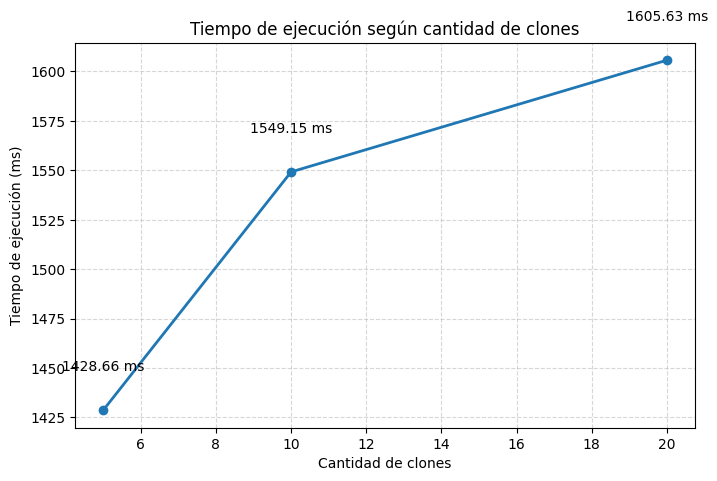

In [ ]:
import matplotlib.pyplot as plt

# Datos
clones = [5, 10, 20]
tiempo = [1428.66, 1549.15, 1605.63]

# Crear gráfico
plt.figure(figsize=(8, 5))

plt.plot(clones, tiempo, marker='o', linewidth=2)

# Títulos y etiquetas
plt.title("Tiempo de ejecución según cantidad de clones")
plt.xlabel("Cantidad de clones")
plt.ylabel("Tiempo de ejecución (ms)")

# Mostrar los valores sobre cada punto
for x, y in zip(clones, tiempo):
    plt.text(x, y + 20, f"{y:.2f} ms", ha='center')

# Cuadrícula
plt.grid(True, linestyle='--', alpha=0.5)

# Mostrar gráfico
plt.show()



##Conclusiones: ¿Cuál es la cantidad óptima de clones?
La cantidad óptima de clones depende del hardware y del objetivo buscado. Al aumentar la cantidad de clones, el nivel alcanzado aumenta aproximadamente de forma lineal, mientras que el tiempo de ejecución tiende a mantenerse relativamente estable mientras la cantidad de hilos pueda ejecutarse concurrentemente. Tambien hay que tener en cuenta el no determinismo de los intentos (chakra y probabilidad aleatoria) de este ejercicio.
Una cantidad excesiva de hilos introduciria overhead por su creación y administración, pudiendo aumentar el tiempo de ejecución. Por lo tanto, la cantidad óptima será aquella que permita obtener un buen nivel en el menor tiempo.
En este caso, 20 clones es mejor que 5: se cuadruplicó el nivel alcanzado (de 24 a 83) manteniendo prácticamente el mismo tiempo de ejecución (~1.5 segundos). 20 es un número de hilos que el hardware administra sin saturarse.